## Plot results of simulation estimation run 

Please refer to the notebook ari_test_notebook.ipynb for explanaiton of the data creation.  

We collect that data and plot it.  To make the code less bulky, we try to abstract away the parameter settings.  

In [1]:
# imports and settings 
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import dill as pickle

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.figsize': (15, 10),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2,
    'lines.markersize': 7,
    'errorbar.capsize': 4,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman'],
    'text.usetex': False,
})

EXPERIMENTS = [ 
    # This helps to loop through uniform plot functions 
    {
        'filename': 'results_varying_n.pkl',
        'param_name': 'n',
        'x_label': 'Network Size (n)',
        'title': 'Effect of Network Size',
        'save_name': 'varying_n.pdf'
    },
    {
        'filename': 'results_varying_T.pkl',
        'param_name': 'T',
        'x_label': 'Time Points (T)',
        'title': 'Effect of Number of Time Points',
        'save_name': 'varying_T.pdf'
    },
    {
        'filename': 'results_varying_rho_difference.pkl',
        'param_name': 'rho_triplet',
        'x_label': 'Connection Probability Triplet (ρ₁, ρ₂, ρ₃)',
        'title': r'Effect of $\rho$ Separation',
        'save_name': 'varying_rho_difference.pdf'
    },
    {
        'filename': 'results_varying_rho_magnitude.pkl',
        'param_name': 'rho_triplet',
        'x_label': 'Connection Probability Triplet (ρ₁, ρ₂, ρ₃)',
        'title': r'Effect of $\rho$ Magnitude',
        'save_name': 'varying_rho_magnitude.pdf'
    },
    {
        'filename': 'results_varying_stay_probs.pkl',
        'param_name': 'stay_probs',
        'x_label': 'Stay Probability',
        'title': 'Effect of Community Stability',
        'save_name': 'varying_stay_probs.pdf'
    }
]



In [2]:
def load_results(filename, output_dir="output/stabilized"):
    # slightly expanded unpickler.  

    filepath = os.path.join(output_dir, filename)
    
    try:
        with open(filepath, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        if 'numpy' in str(e):
        # There can be issues when pickling and unpickling are done using 
        # different numpy versions.   This is because 
        # numpy < 2. uses numpy._core, >= 2. uses numpy.core.  
        # See  https://github.com/numpy/numpy/issues/24844 for a discussion about this issue.   
        # ngoldbaum mentions "there is probably an easy hacky workaround" there.  
        # This is an easy hacky workaround that worked for me.  
        # NB, this is only an issue if you use two different python systems for calculation and plotting.  
            try:
                import pickle as std_pickle
                
                class FixedUnpickler(std_pickle.Unpickler):
                    # We just have to overwrite the find_class method a little bit.  
                    def find_class(self, module, name):
                        if module == 'numpy._core.multiarray':
                            module = 'numpy.core.multiarray'
                        elif module.startswith('numpy._core'):
                            module = module.replace('numpy._core', 'numpy.core')
                        return super().find_class(module, name)
                
                with open(filepath, 'rb') as f:
                    return FixedUnpickler(f).load()
            except Exception as e2:  # if that did not help, we give up.    
                raise
        else:
            raise

def extract_numeric_values(keys):
    # We had to encode our numerical parameters into dict strings for pickling.  
    # This extracts them back into floats, or tuples of floats.  
    numeric_vals = []
    for key in keys:
        try:
            numeric_vals.append(float(key))
        except:
            if key.startswith('(') and key.endswith(')'):
                values = key.strip('()').split(',')
                numeric_vals.append(float(values[2]))
            elif key.startswith('[') and key.endswith(']'):
                values = key.strip('[]').split(',')
                numeric_vals.append(float(values[0]))
            else:
                numeric_vals.append(0)
    return numeric_vals

def plot_experiment(ax, results, param_name, x_label, title):
    param_keys = [k for k in results.keys() if k != 'info' and 'error' not in results.get(k, {})]
    
    # Check if parameters are purely numeric
    is_numeric = all(k.replace('.', '').isdigit() for k in param_keys)
    
    if is_numeric:
        # Use actual numeric values for x-axis
        numeric_vals = [float(k) for k in param_keys]
        sorted_indices = np.argsort(numeric_vals)
        param_keys = [param_keys[i] for i in sorted_indices]
        x_values = np.array([numeric_vals[i] for i in sorted_indices])
    else:
        # Use evenly spaced integers for non-numeric parameters
        numeric_vals = extract_numeric_values(param_keys)
        sorted_indices = np.argsort(numeric_vals)
        param_keys = [param_keys[i] for i in sorted_indices]
        x_values = np.arange(len(param_keys))
    
    super_ari_means = np.array([results[k]['super_ari'] for k in param_keys])
    super_ari_stds = np.array([results[k].get('super_ari_std', 0) for k in param_keys])
    mean_ari_means = np.array([results[k]['mean_ari'] for k in param_keys])
    mean_ari_stds = np.array([results[k].get('mean_ari_std', 0) for k in param_keys])
    
    col_blue = '#1f77b4'
    col_orange = '#ff7f0e'

    # plot mean values 
    ax.plot(
        x_values, super_ari_means, 
        'o-', label='Super ARI', 
        color=col_blue, markersize=8, linewidth=2.5)
    ax.plot(
        x_values, mean_ari_means, 
        's-', label='Mean ARI', 
        color=col_orange, markersize=7, linewidth=2.5
    )

    # and error bars 
    ax.fill_between(
        x_values, super_ari_means - super_ari_stds, 
        super_ari_means + super_ari_stds,
        alpha=0.3, color=col_blue
        )
    
    ax.fill_between(
        x_values, 
        mean_ari_means - mean_ari_stds, 
        mean_ari_means + mean_ari_stds,
        alpha=0.3, color=col_orange
    )
    
    ax.set_xlabel(x_label)
    ax.set_ylabel('ARI Score')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.minorticks_on()
    ax.grid(which='minor', alpha=0.1, linestyle=':')
    
    # custom tick labels
    if not is_numeric:
        ax.set_xticks(x_values)
        ax.set_xticklabels(param_keys, rotation=30, ha='right')

def plot_timing(ax, results_n, results_T):

    # log/log plots of time vs number of parameters 

    # Default values for fixed parameters
    default_T = 20  # Default T when varying n
    default_n = 1000  # Default n when varying T
    
    # Extract timing data for varying n
    param_keys_n = [k for k in results_n.keys() if k != 'info' and 'error' not in results_n.get(k, {})]
    n_values = extract_numeric_values(param_keys_n)
    sorted_indices_n = np.argsort(n_values)
    n_values_sorted = np.array([n_values[i] for i in sorted_indices_n])
    time_means_n = np.array([results_n[param_keys_n[i]]['estimation_time'] for i in sorted_indices_n])
    time_stds_n = np.array([results_n[param_keys_n[i]]['estimation_time_std'] for i in sorted_indices_n])
    
    
    # Extract timing data for varying T
    param_keys_T = [k for k in results_T.keys() if k != 'info' and 'error' not in results_T.get(k, {})]
    T_values = extract_numeric_values(param_keys_T)
    sorted_indices_T = np.argsort(T_values)
    T_values_sorted = np.array([T_values[i] for i in sorted_indices_T])
    time_means_T = np.array([results_T[param_keys_T[i]]['estimation_time'] for i in sorted_indices_T])
    time_stds_T = np.array([results_T[param_keys_T[i]].get('estimation_time_std', 0) for i in sorted_indices_T])

    # x axis values 
    x_values_n = default_T * n_values_sorted * (n_values_sorted - 1) / 2
    x_values_T = T_values_sorted * default_n * (default_n - 1) / 2

    ax.errorbar(
        x_values_n, 
        time_means_n, 
        yerr=time_stds_n, 
        fmt='o-', 
        label='Varying n (T=20)', 
        color='green', 
        markersize=8, linewidth=2.5, capsize=5
    )
    
    ax.errorbar(
        x_values_T, 
        time_means_T, 
        yerr=time_stds_T, 
        fmt='^-', 
        label='Varying T (n=1000)', 
        color='red', 
        markersize=8, linewidth=2.5, capsize=5
    )
    
    ax.set_xlabel(r'$T \cdot n \cdot (n-1) / 2$')
    ax.set_ylabel('Computation Time (seconds)')
    ax.set_title('Algorithm Run Time')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--', which='both')
    ax.minorticks_on()

def create_combined_plot(output_dir="output/stabilized", save_path="experiment_results.pdf", v_spacing=0.4):
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 2, figure=fig, hspace=v_spacing, wspace=0.3)
    
    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, 0]),
        fig.add_subplot(gs[2, 1])
    ]
    
    # We can add the experiments in a loop 
    for ax, exp in zip(axes[:5], EXPERIMENTS):
        results = load_results(exp['filename'], output_dir)
        plot_experiment(ax, results, exp['param_name'], exp['x_label'], exp['title'])
    
    # and have a special call for the time plot 
    results_n = load_results('results_varying_n.pkl', output_dir)
    results_T = load_results('results_varying_T.pkl', output_dir)
    plot_timing(axes[5], results_n, results_T)
       
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()


C:\Users\jcreu\AppData\Local\Temp\ipykernel_14728\3605762700.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


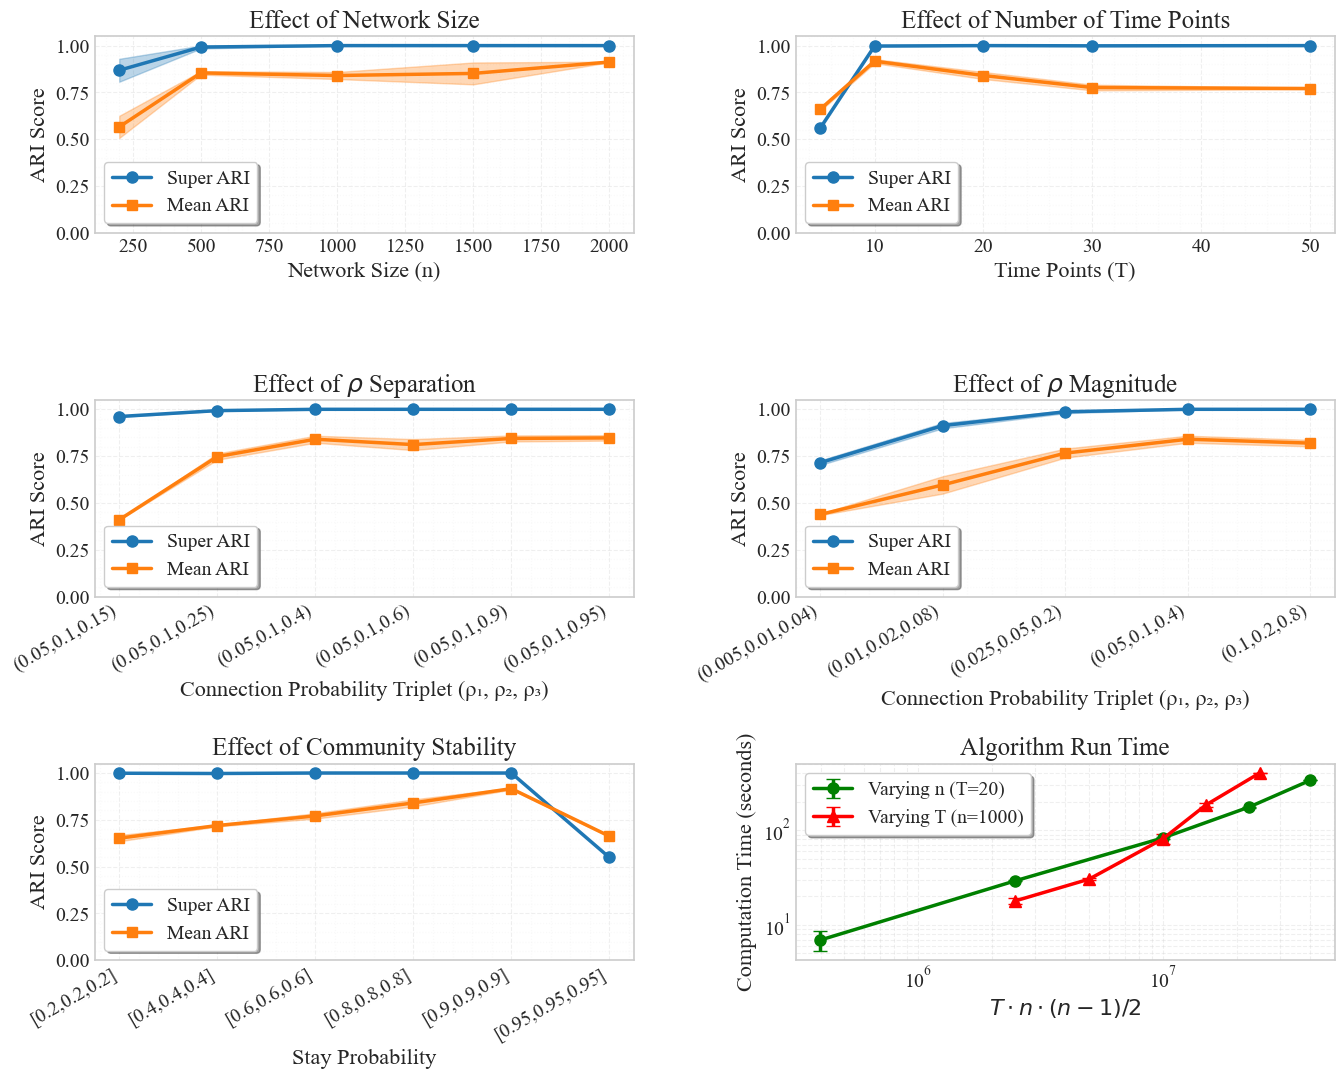

FileNotFoundError: [Errno 2] No such file or directory: 'output/simple\\results_varying_n.pkl'

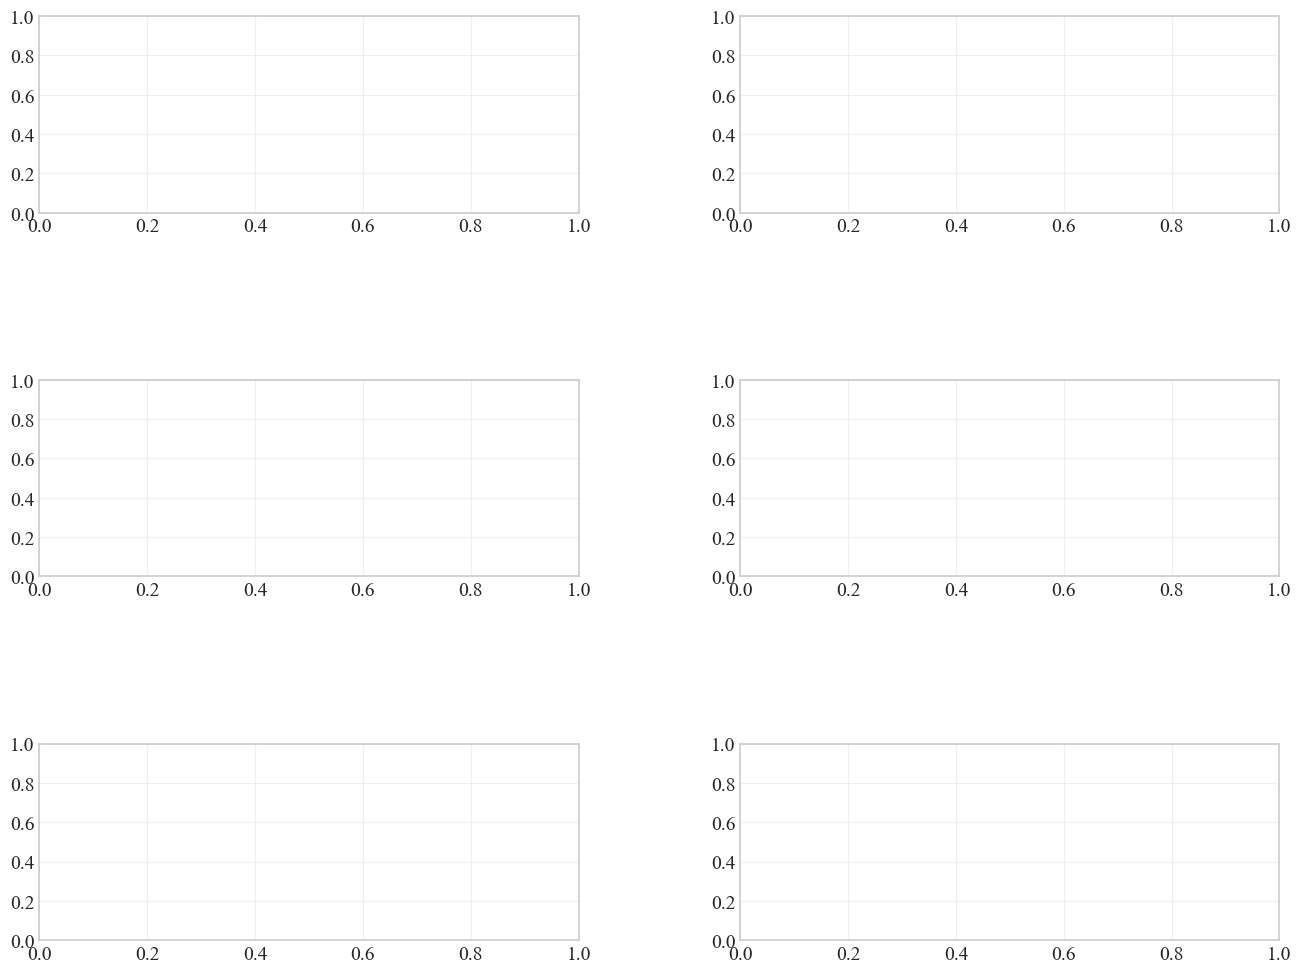

In [3]:
create_combined_plot(v_spacing=0.85, output_dir="output/stabilized", save_path="output/stabilized/combined_plot.pdf")  
create_combined_plot(v_spacing=0.85, output_dir="output/simple", save_path="output/simple/combined_plot.pdf")  
